# LSTM RNN for Dynamic Foraging Task

Two goals:
1. **Match animal behavior** – train an LSTM to predict trial-by-trial choices on a real session.
2. **Predict neural activity** – use behavioral regressors as LSTM inputs to decode neural population data.

Data loading and training utilities are recycled directly from `vanilla_rnn.ipynb`.

## Imports

In [1]:
import os
import pickle
import random
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Add repo/src to sys.path so rnn_utils and data_io are importable.
try:
    _nb_dir = Path(__file__).resolve().parent
except NameError:
    _nb_dir = Path.cwd()

for _candidate in [_nb_dir, _nb_dir.parent]:
    _src = _candidate / "src"
    if _src.exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

from rnn_utils import (
    TaskConfig,
    TwoArmedBanditBlockTask,
    sample_training_batch,
    moving_average,
    LSTMBehavior,
    LSTMNeural,
    train_model,
    train_on_real_session,
    train_neural_rnn,
    create_neural_targets_from_psth,
    align_behavior_and_neural,
    run_closed_loop_lstm,
    plot_block_choice_panel,
    plot_pright_animal_vs_model,
    compute_unit_r2,
    plot_unit_trial_psth_overlays,
    visualize_neural_predictions,
)
from data_io import vectorize_labels

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

Using device: mps


## LSTM Architecture

Two model classes built on `torch.nn.LSTM`:

* **`LSTMBehavior`** – classification head (cross-entropy); predicts left/right choice.
* **`LSTMNeural`** – regression head (MSE); decodes continuous neural activity.

Both expose the same `forward(x, state=None) -> (output, state)` interface as the
vanilla rate-RNN models so that all training and visualization helpers from
`rnn_utils` can be used without modification.

In [2]:
print(f"LSTMBehavior and LSTMNeural imported from rnn_utils.")
print(f"  LSTMBehavior: {LSTMBehavior}")
print(f"  LSTMNeural:   {LSTMNeural}")

LSTMBehavior and LSTMNeural defined.


## Part 1 – Match Animal Behavior

### 1a. Train LSTM on the Synthetic Task

First verify the LSTM can learn the alternating-block bandit task from scratch (same task as in `vanilla_rnn.ipynb`).

In [3]:
task_cfg = TaskConfig(
    min_block_len=15,
    max_block_len=20,
    p_high=1.0,
    p_low=0.0,
    total_trials=180,
)
task = TwoArmedBanditBlockTask(task_cfg)

synth_model = LSTMBehavior(
    input_size=4,
    hidden_size=100,
    num_layers=1,
    output_size=2,
).to(DEVICE)

# train_model from rnn_utils is compatible: it calls model(X) -> (logits, _)
loss_hist, acc_hist = train_model(
    synth_model,
    task,
    steps=250,
    batch_size=128,
    lr=1e-3,
    grad_clip=2.0,
    print_every=20,
    device=DEVICE,
)

step   20 | loss 0.6834 | acc 0.553
step   40 | loss 0.5701 | acc 0.838
step   60 | loss 0.4011 | acc 0.830
step   80 | loss 0.3607 | acc 0.846
step  100 | loss 0.2992 | acc 0.877
step  120 | loss 0.2439 | acc 0.900
step  140 | loss 0.1923 | acc 0.922
step  160 | loss 0.1783 | acc 0.926
step  180 | loss 0.1523 | acc 0.938
step  200 | loss 0.1455 | acc 0.934
step  220 | loss 0.1332 | acc 0.944
step  240 | loss 0.1242 | acc 0.950


#### Plot training curves

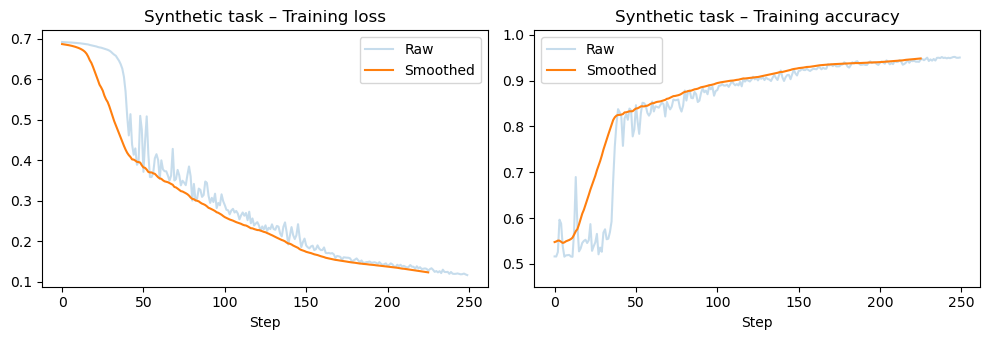

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(loss_hist, alpha=0.25, label="Raw")
axes[0].plot(moving_average(loss_hist, 25), label="Smoothed")
axes[0].set_title("Synthetic task – Training loss")
axes[0].set_xlabel("Step")
axes[0].legend()

axes[1].plot(acc_hist, alpha=0.25, label="Raw")
axes[1].plot(moving_average(acc_hist, 25), label="Smoothed")
axes[1].set_title("Synthetic task – Training accuracy")
axes[1].set_xlabel("Step")
axes[1].set_ylim(0.45, 1.01)
axes[1].legend()
plt.tight_layout()
plt.show()

#### Closed-loop simulation

Run the trained LSTM in a closed loop (its own predictions feed back as inputs) to
visualize block-switching behavior.  The LSTM state is carried step-by-step as the
`(h, c)` tuple.

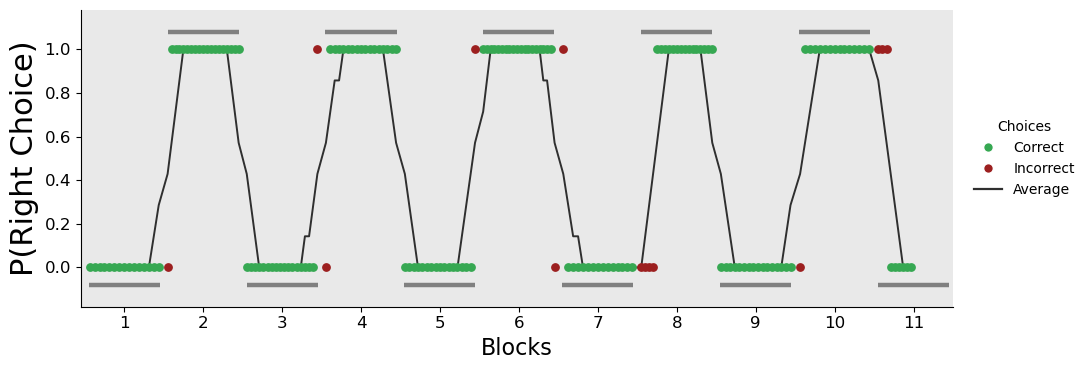

In [5]:
session_for_plot = run_closed_loop_lstm(
    synth_model, task, seed=42, temperature=1.0, epsilon=0.02, device=DEVICE
)
plot_block_choice_panel(session_for_plot, smooth_window=7)

### 1b. Train LSTM to Match Real Animal Behavior

Load one behavioral session and train `LSTMBehavior` to predict the animal's
observed choices.  The data loading and feature construction is identical to
`vanilla_rnn.ipynb`.

In [6]:
# ── Data paths ────────────────────────────────────────────────────────────────
# DATA_ROOT is the top-level directory that contains <animal>/<session>/ folders.
# Set the DATA_ROOT environment variable when running on a remote machine (e.g. GCP).
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/Users/lsye/DynamicForagingNPanalysis/data"))

ANIMAL  = "MM012"
SESSION = "20231211_172819"
SESSION_DIR    = DATA_ROOT / ANIMAL / SESSION
TRIALDATA_PATH = SESSION_DIR / "trialdata.csv"

trialdata    = pd.read_csv(TRIALDATA_PATH)
session_data = {"MFblocks": [], "MBblocks": []}   # not required for choice/history features

# ── Build behavioral feature matrix (same as vanilla_rnn.ipynb) ───────────────
# Inputs: [prev_action_left, prev_action_right, prev_reward, trial_start]
prev_action_left  = vectorize_labels(trialdata, session_data, "prev_choice_left",  rewarded_only=False)
prev_action_right = vectorize_labels(trialdata, session_data, "prev_choice_right", rewarded_only=False)
prev_reward       = vectorize_labels(trialdata, session_data, "prev_reward",        rewarded_only=False)
trial_start       = vectorize_labels(trialdata, session_data, "trial_start",        rewarded_only=False)

# Target: observed animal choice (left=0, right=1)
y_real = vectorize_labels(trialdata, session_data, "choice", rewarded_only=False).astype(np.int64)

X_real = np.column_stack([
    prev_action_left,
    prev_action_right,
    prev_reward,
    trial_start,
]).astype(np.float32)

assert X_real.shape[0] == y_real.shape[0], "Input/target lengths must match."

# Single-session tensor shape: [batch=1, time, features]
X_real_torch = torch.tensor(X_real, dtype=torch.float32, device=DEVICE).unsqueeze(0)
y_real_torch = torch.tensor(y_real, dtype=torch.long,    device=DEVICE).unsqueeze(0)

print(f"Loaded session : {ANIMAL}/{SESSION}")
print("X_real_torch shape:", tuple(X_real_torch.shape))
print("y_real_torch shape:", tuple(y_real_torch.shape))
print("Right-choice fraction:", round(float(y_real.mean()), 3))

Loaded session : MM012/20231211_172819
X_real_torch shape: (1, 337, 4)
y_real_torch shape: (1, 337)
Right-choice fraction: 0.531


#### Train

In [7]:
animal_model = LSTMBehavior(
    input_size=X_real_torch.shape[-1],
    hidden_size=128,
    num_layers=1,
    output_size=2,
).to(DEVICE)

# train_on_real_session from rnn_utils calls model(X_seq) -> (logits, _)
real_loss_hist, real_acc_hist = train_on_real_session(
    animal_model,
    X_real_torch,
    y_real_torch,
    epochs=600,
    lr=1e-3,
    grad_clip=1.0,
    print_every=50,
)

with torch.no_grad():
    logits_final, _ = animal_model(X_real_torch)
    final_acc = (logits_final.argmax(-1) == y_real_torch).float().mean().item()
print(f"\nFinal fit accuracy on session: {final_acc:.3f}")

epoch   50 | loss 0.3979 | acc 0.819
epoch  100 | loss 0.3556 | acc 0.846
epoch  150 | loss 0.3069 | acc 0.864
epoch  200 | loss 0.3437 | acc 0.858
epoch  250 | loss 0.3455 | acc 0.858
epoch  300 | loss 0.2637 | acc 0.890
epoch  350 | loss 0.2765 | acc 0.878
epoch  400 | loss 0.2415 | acc 0.893
epoch  450 | loss 0.2250 | acc 0.899
epoch  500 | loss 0.5381 | acc 0.777
epoch  550 | loss 0.3218 | acc 0.864
epoch  600 | loss 0.2772 | acc 0.875

Final fit accuracy on session: 0.878


#### Plot training curves

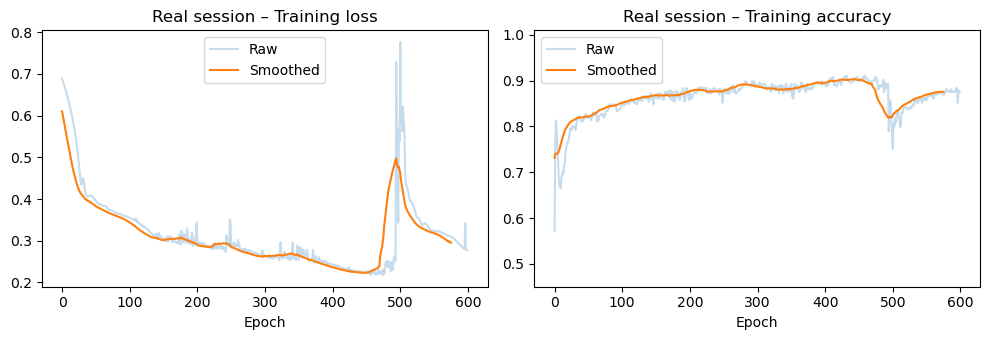

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(real_loss_hist, alpha=0.25, label="Raw")
axes[0].plot(moving_average(real_loss_hist, 25), label="Smoothed")
axes[0].set_title("Real session – Training loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(real_acc_hist, alpha=0.25, label="Raw")
axes[1].plot(moving_average(real_acc_hist, 25), label="Smoothed")
axes[1].set_title("Real session – Training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0.45, 1.01)
axes[1].legend()
plt.tight_layout()
plt.show()

#### Compare animal choices vs. LSTM predictions

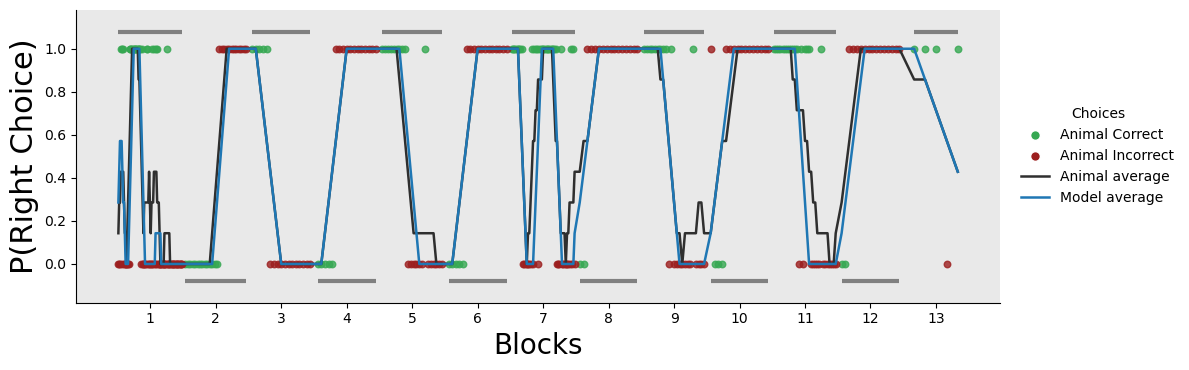

In [9]:
animal_model.eval()
with torch.no_grad():
    logits_pred, _ = animal_model(X_real_torch)
    y_model_pred = logits_pred.argmax(dim=-1)[0].cpu().numpy()   # [T]

plot_pright_animal_vs_model(
    trialdata, y_real, y_model_pred, smooth_window=7, mode="overlay"
)

---

## Part 2 – Predict Neural Activity from Behavioral Regressors

Use an expanded set of behavioral regressors (block ID, current/previous choice,
current/previous reward, strategy label) as LSTM inputs to predict population
neural activity (trial-averaged PSTHs).

### 2a. Build neural targets

In [10]:
# Match df_dm: pres=1, posts=2 -> window -1 to +2 s (30 bins at 100ms)
neural_targets_dict, neural_meta = create_neural_targets_from_psth(
    animal_name=ANIMAL,
    session=SESSION,
    data_root=str(DATA_ROOT),
    trial_period="choice",
    rewarded_only=False,
    probes=("imec0", "imec1"),
    binwidth_ms=100,
    tpre=1,
    tpost=2,
)

TARGET_KEY = next(iter(neural_targets_dict))
print("Available targets:", list(neural_targets_dict.keys()))
print("Using          :", TARGET_KEY, "| shape:", neural_targets_dict[TARGET_KEY].shape)

imec0:ACC excluded 25 unit(s) with mean rate < 1.0 Hz
imec0:DMS excluded 13 unit(s) with mean rate < 1.0 Hz
imec1:M2 excluded 15 unit(s) with mean rate < 1.0 Hz
imec1:DLS excluded 16 unit(s) with mean rate < 1.0 Hz
Available targets: ['imec0_ACC', 'imec0_DMS', 'imec1_M2', 'imec1_DLS']
Using          : imec0_ACC | shape: (337, 2280)


### 2b. Build behavioral regressor matrix

In [11]:
# Load behavioral regressor matrix from dmat-early.npz (matches vanilla_rnn, df_dm)
# df_dm: BWMS=10 (10ms bins), pres=1, posts=2 -> 299 bins/trial, window -1 to +2 s
# Early session 20231211_172819 -> dmat-early.npz; late 20231225_123125 -> dmat-late.npz
_repo = Path.cwd()
for _c in [Path.cwd(), Path.cwd().parent]:
    if (_c / "data" / "dmat-early.npz").exists():
        _repo = _c
        break
DMAT_PATH = _repo / "data" / "dmat-early.npz"

dmat_data = np.load(DMAT_PATH)
X_dmat = dmat_data["X"].astype(np.float32)

n_rows, n_regressors = X_dmat.shape
n_bins_per_trial = 299
n_trials_dmat = n_rows // n_bins_per_trial
n_bins_total = n_trials_dmat * n_bins_per_trial
X_dmat_reshaped = X_dmat[:n_bins_total].reshape(n_trials_dmat, n_bins_per_trial, n_regressors)
X_neural_behavior = X_dmat_reshaped.mean(axis=1).astype(np.float32)

# Align trial counts between behavior and neural data
X_neural, Y_neural = align_behavior_and_neural(
    X_neural_behavior, neural_targets_dict[TARGET_KEY]
)

X_neural_torch = torch.tensor(X_neural, dtype=torch.float32, device=DEVICE).unsqueeze(0)
Y_neural_torch = torch.tensor(Y_neural, dtype=torch.float32, device=DEVICE).unsqueeze(0)

print("Regressors from dmat-early.npz:", n_regressors, "features,", X_neural.shape[0], "trials")
print("X_neural_torch shape :", tuple(X_neural_torch.shape))
print("Y_neural_torch shape :", tuple(Y_neural_torch.shape))

Regressors from dmat-early.npz: 184 features, 336 trials
X_neural_torch shape : (1, 336, 184)
Y_neural_torch shape : (1, 336, 2280)


### 2c. Initialise and train LSTMNeural

In [34]:
neural_model = LSTMNeural(
    input_size=X_neural_torch.shape[-1],
    hidden_size=128,
    num_layers=2,
    output_size=Y_neural_torch.shape[-1],
).to(DEVICE)

print("LSTMNeural  input_size :", X_neural_torch.shape[-1])
print("LSTMNeural  hidden_size:", neural_model.hidden_size)
print("LSTMNeural  output_size:", Y_neural_torch.shape[-1])
total_params = sum(p.numel() for p in neural_model.parameters())
print(f"Total parameters       : {total_params:,}")

LSTMNeural  input_size : 184
LSTMNeural  hidden_size: 128
LSTMNeural  output_size: 2280
Total parameters       : 586,984


In [35]:
# train_neural_rnn from rnn_utils calls model(X_seq) -> (y_hat, _) and optimises MSE
neural_loss_hist, neural_ve_hist = train_neural_rnn(
    neural_model,
    X_neural_torch,
    Y_neural_torch,
    epochs=2000,
    lr=1e-4,
    grad_clip=5.0,
    print_every=50,
)

epoch   50 | mse 246.691376 | var_explained -0.258
epoch  100 | mse 233.558090 | var_explained -0.191
epoch  150 | mse 220.854797 | var_explained -0.126
epoch  200 | mse 211.774658 | var_explained -0.080
epoch  250 | mse 204.750458 | var_explained -0.044
epoch  300 | mse 198.907227 | var_explained -0.014
epoch  350 | mse 193.859024 | var_explained 0.011
epoch  400 | mse 189.406097 | var_explained 0.034
epoch  450 | mse 185.424911 | var_explained 0.054
epoch  500 | mse 181.834274 | var_explained 0.073
epoch  550 | mse 178.574402 | var_explained 0.089
epoch  600 | mse 175.599518 | var_explained 0.104
epoch  650 | mse 172.873993 | var_explained 0.118
epoch  700 | mse 170.368912 | var_explained 0.131
epoch  750 | mse 168.060318 | var_explained 0.143
epoch  800 | mse 165.928101 | var_explained 0.154
epoch  850 | mse 163.955307 | var_explained 0.164
epoch  900 | mse 162.126923 | var_explained 0.173
epoch  950 | mse 160.429611 | var_explained 0.182
epoch 1000 | mse 158.851791 | var_explained 

#### Plot neural training curves

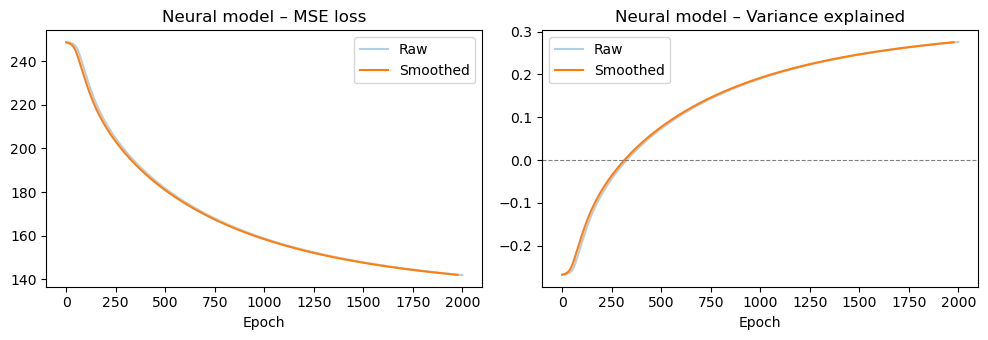

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(neural_loss_hist, alpha=0.35, label="Raw")
axes[0].plot(moving_average(neural_loss_hist, 25), label="Smoothed")
axes[0].set_title("Neural model – MSE loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(neural_ve_hist, alpha=0.35, label="Raw")
axes[1].plot(moving_average(neural_ve_hist, 25), label="Smoothed")
axes[1].set_title("Neural model – Variance explained")
axes[1].set_xlabel("Epoch")
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].legend()
plt.tight_layout()
plt.show()

### 2d. Evaluate and visualise neural predictions

Mean R² (valid units): -0.542
Units with R² > 0    : 0 / 76


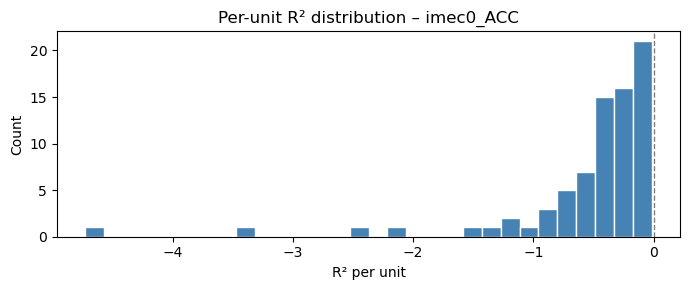

In [25]:
# Per-unit R² across all trials
neural_model.eval()
with torch.no_grad():
    y_hat_np = neural_model(X_neural_torch)[0][0].cpu().numpy()   # [T, D]
y_true_np = Y_neural_torch[0].cpu().numpy()                       # [T, D]

n_units = int(neural_meta[TARGET_KEY]["n_units"])
n_bins  = int(neural_meta[TARGET_KEY]["n_timebins"])
T       = min(y_hat_np.shape[0], y_true_np.shape[0])

y_hat_3d  = y_hat_np[:T].reshape(T, n_units, n_bins)
y_true_3d = y_true_np[:T].reshape(T, n_units, n_bins)

r2_per_unit = compute_unit_r2(y_true_3d, y_hat_3d)
valid_r2    = r2_per_unit[~np.isnan(r2_per_unit)]

print(f"Mean R² (valid units): {np.mean(valid_r2):.3f}")
print(f"Units with R² > 0    : {np.sum(valid_r2 > 0)} / {len(valid_r2)}")

plt.figure(figsize=(7, 3))
plt.hist(valid_r2, bins=30, color="steelblue", edgecolor="white")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.xlabel("R² per unit")
plt.ylabel("Count")
plt.title(f"Per-unit R² distribution – {TARGET_KEY}")
plt.tight_layout()
plt.show()

/Users/lsye/anaconda3/envs/spks/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/lsye/anaconda3/envs/spks/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


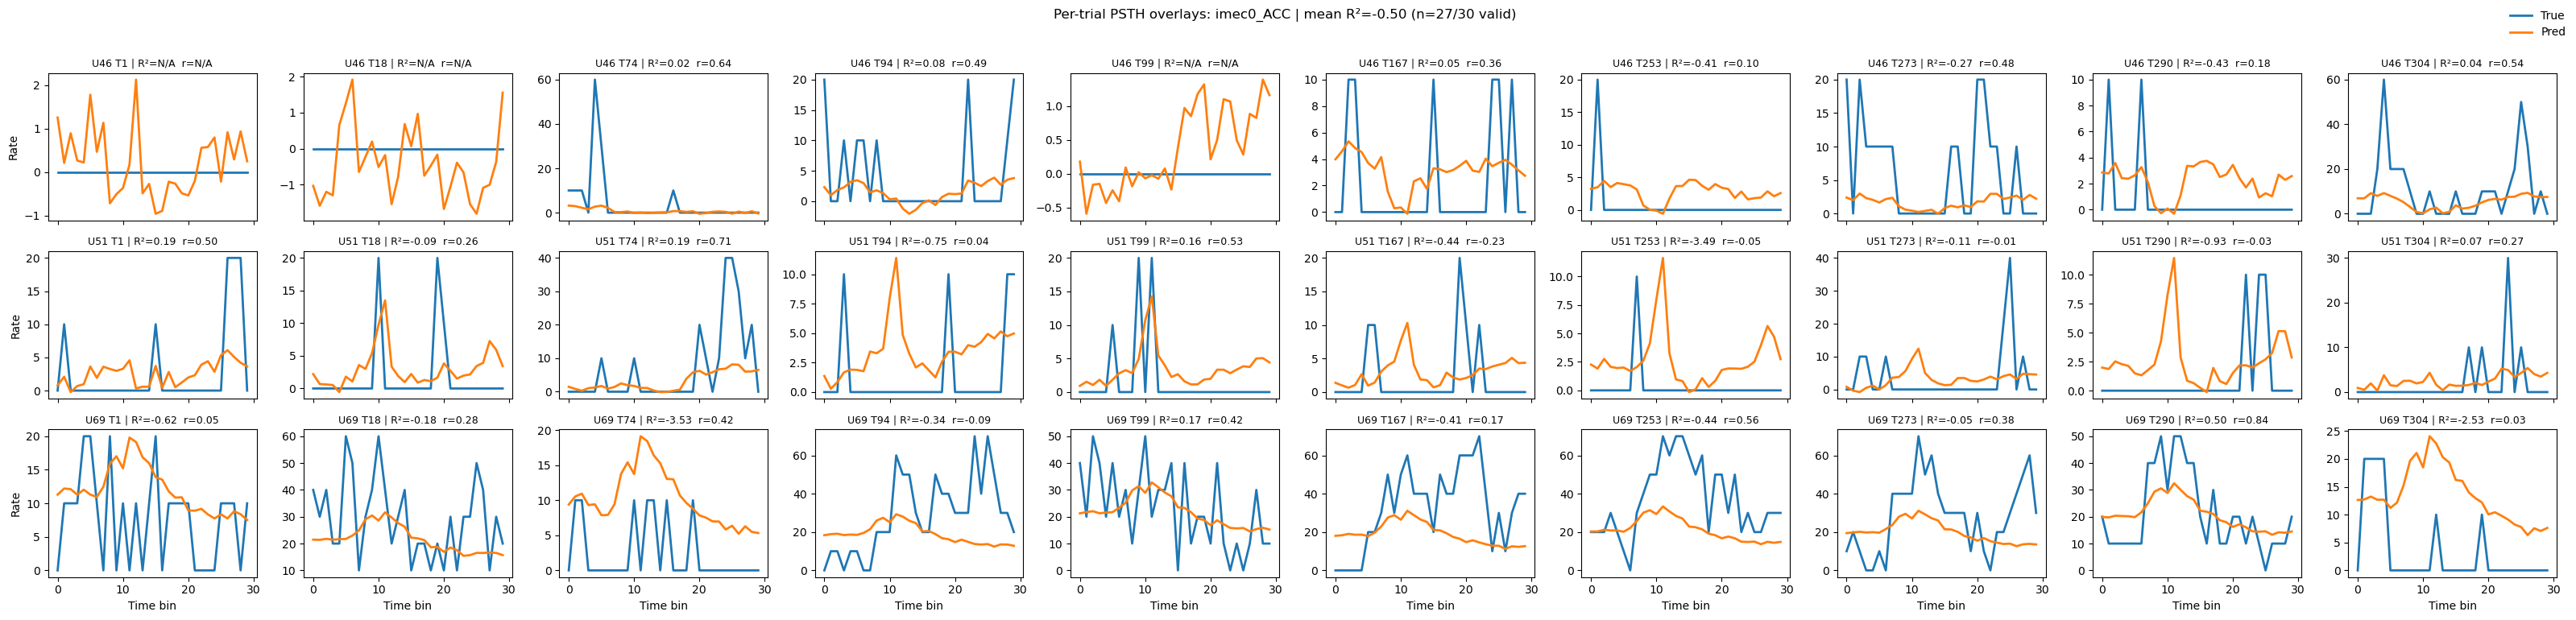

In [16]:
# Per-trial PSTH overlays for a random selection of units and trials
plot_unit_trial_psth_overlays(
    neural_model,
    X_neural_torch,
    Y_neural_torch,
    neural_meta,
    TARGET_KEY,
    n_units=3,
    n_trials=10,
    seed=SEED,
)

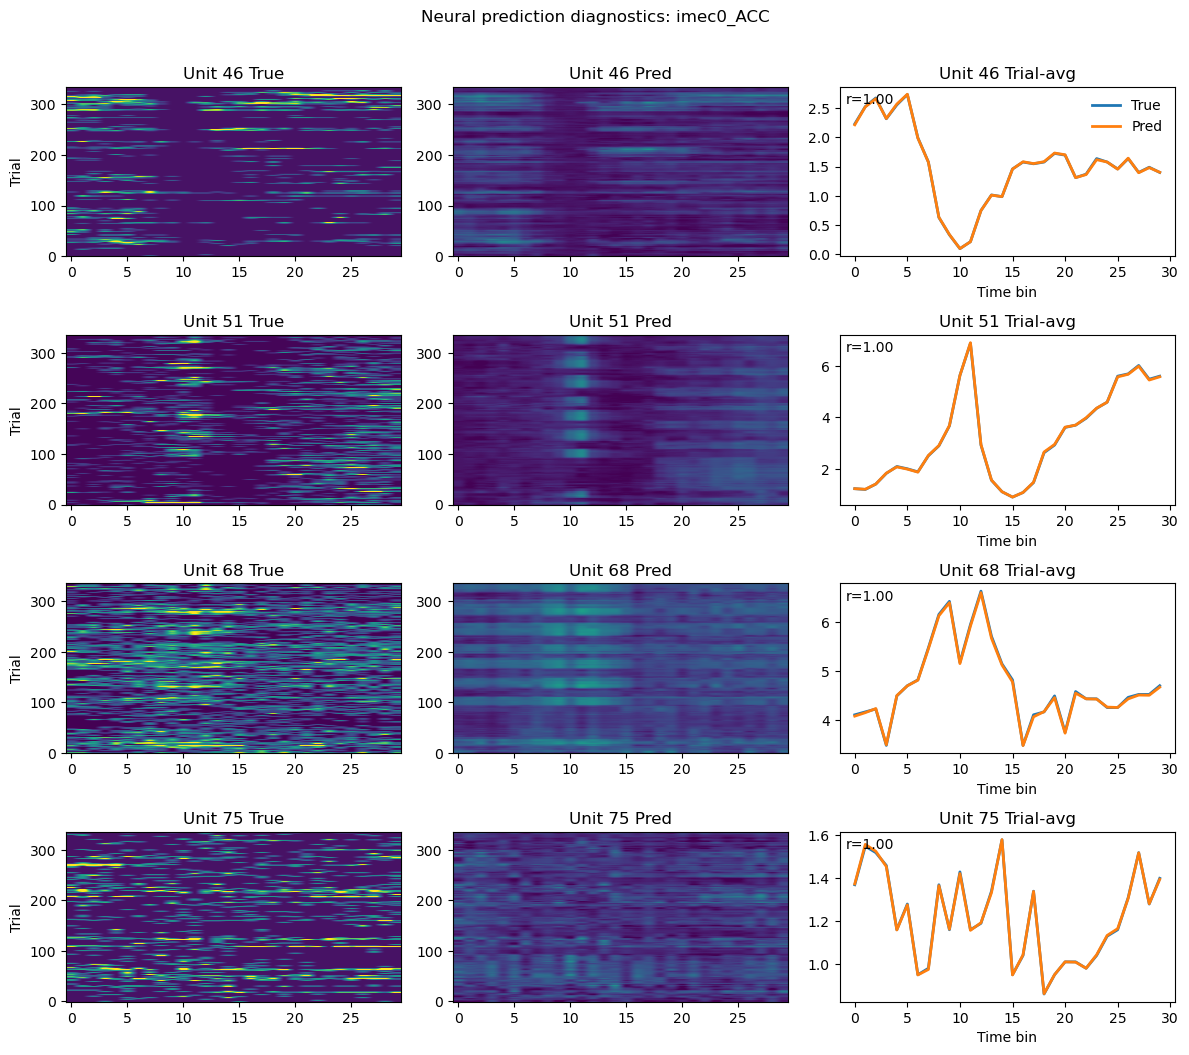

In [17]:
# Heatmap + trial-averaged prediction diagnostics
visualize_neural_predictions(
    neural_model,
    X_neural_torch,
    Y_neural_torch,
    neural_meta,
    TARGET_KEY,
    n_units_to_plot=4,
    random_seed=SEED,
)